In [1]:
# generic imports
import numpy as np
import os
import copy
import time
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.signal import decimate
from scipy.io import loadmat


# respymethods import
from respymethods.GenerateSurrogates import iaaft
from respymethods.PhaseExtraction import two_point_interp
from respymethods.Helpers import plv, prune_nan
from respymethods.Simulation import create_phase_bins


In [2]:
# Parameters
# other configs that might be put as input in some future versions
# for the time being brutally defaulted here
orgfs = 600; # original sampling frequency of raw data
fs = 100; # final sampling frequency after downsampling
downsmpl_rate = int(orgfs/fs) # if >13, not recomendations from sp.signal.decimate doc
win_len = int(.4*orgfs)
crit_z = 1 # !!! still unused !!!. Does it make sense to have such limit only for peaks?
crit_plv = .1
n_iter = 500 # low number for demonstration sake
nbin = 60

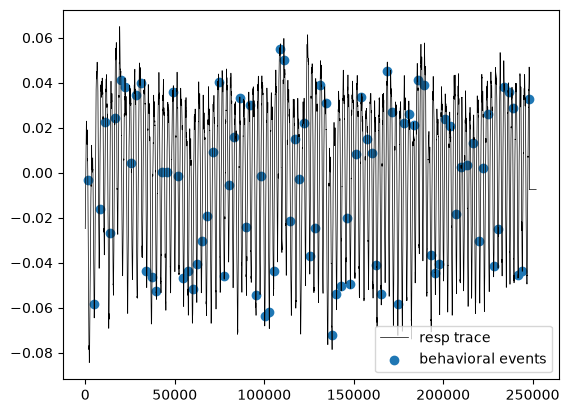

In [3]:
# Load and display data
resp_trace = loadmat("exampledata/resp_raw_001.mat")["data"][0]
# load behavioral events
events = loadmat("exampledata/events.mat")["events"][0][0][0][0]

plt.plot(resp_trace, color="k", linewidth=.5)
plt.scatter(events[0], resp_trace[events[0]])
plt.legend(("resp trace", "behavioral events"))

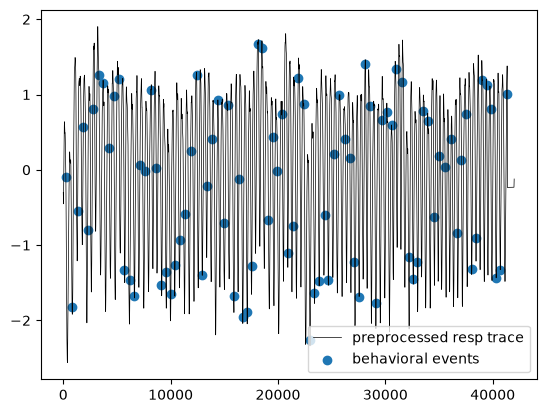

In [4]:
# 1. Preprocessing
# 1.1 Smoothing
x_smooth = np.convolve(resp_trace, np.ones(win_len), 'same')/win_len
# 1.2 Downsampling
x_down = decimate(x_smooth, downsmpl_rate)
# 1.3 Z scoring
x_norm = zscore(x_down)
# 1.4 Resample behavioral events
dict_events = {"idx_sample" : np.asarray(events[0])//downsmpl_rate,
               "HvsM" : events[1],
              }
dict_events.update({"resp_phase" : x_norm[dict_events["idx_sample"]]})

# plot after transformation
plt.plot(x_norm, color="k", linewidth=.5)
plt.scatter(dict_events["idx_sample"], dict_events["resp_phase"])
plt.legend(("preprocessed resp trace", "behavioral events"))


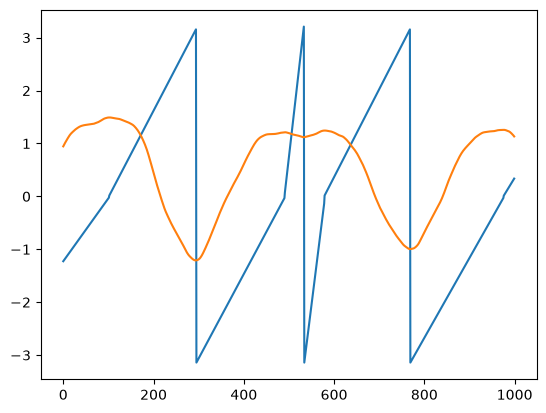

In [5]:
# 2. Phase computation

phase_vect = two_point_interp(x_norm)

plt.plot(phase_vect[1000:2000])
plt.plot(x_norm[1000:2000])


In [6]:
# 3. Generate surrogates
# Time consuming step, please consider parallelizing this. 
# Examples on how to do that in ./advanced_tutorials/Tutorial_DataPrepMultiprocessing.py
surr_data = np.zeros((len(x_norm), n_iter))

i=0;
while i<n_iter:
    
    surr_ = iaaft(x_norm)
    theta_ = two_point_interp(surr_)
    tmp1, tmp2 = prune_nan(phase_vect, theta_)
    this_plv = plv(tmp1, tmp2)
    
    if this_plv<crit_plv:
        surr_data[:, i] = surr_
        i+=1         
        if i%100 == 0:
            print(f"{i}/{n_iter} iterations")


100/500 iterations
200/500 iterations
300/500 iterations
400/500 iterations
500/500 iterations


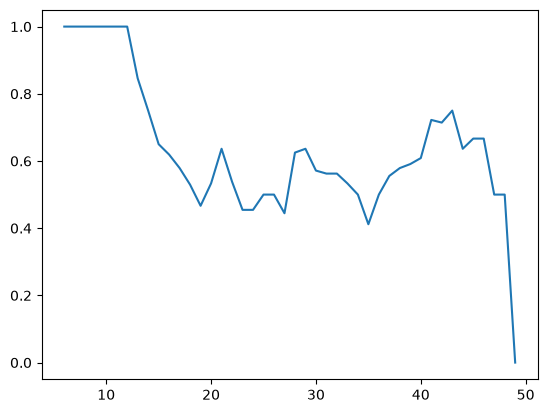

In [12]:
# 4. Bin data
phw = (np.pi/10)
pb = np.linspace(-np.pi,np.pi-2*np.pi/nbin,nbin)
bin_idxs = create_phase_bins(dict_events["resp_phase"], pb, phw)
HR = []
for ibin in bin_idxs:
    HR.append(np.mean(dict_events["HvsM"][ibin]))

plt.plot(HR)


In [ ]:
# 5. Repeat for iterations

